In [1]:
from google.colab import files
uploaded=files.upload()

Saving heart.csv to heart.csv


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
df=pd.read_csv('heart.csv')
x=df.drop('condition',axis=1)
print(x.head())
y=df['condition']
print(y.head())
print(x.shape)
print(y.shape)

   age  sex  cp  trestbps  chol  fbs  ...  thalach  exang  oldpeak  slope  ca  thal
0   69    1   0       160   234    1  ...      131      0      0.1      1   1     0
1   69    0   0       140   239    0  ...      151      0      1.8      0   2     0
2   66    0   0       150   226    0  ...      114      0      2.6      2   0     0
3   65    1   0       138   282    1  ...      174      0      1.4      1   1     0
4   64    1   0       110   211    0  ...      144      1      1.8      1   0     0

[5 rows x 13 columns]
0    0
1    0
2    0
3    1
4    0
Name: condition, dtype: int64
(297, 13)
(297,)


In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x_train)
xtests=scaler.transform(x_test)
model=DecisionTreeClassifier()
model.fit(x_scaled,y_train)
y_predict=model.predict(xtests)
print("DecisionTreee Accuracy_score:",accuracy_score(y_test,y_predict))

Accuracy_score: 0.7


In [49]:
from sklearn.ensemble import BaggingClassifier
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x_train)
xtests=scaler.transform(x_test)
base=DecisionTreeClassifier()
model=BaggingClassifier(estimator=base,n_estimators=100,max_samples=60)
model.fit(x_scaled,y_train)
predict=model.predict(xtests)
print("Bagging Accuracy:",accuracy_score(y_test,predict))
model.estimators_samples_

Bagging Accuracy: 0.75


[array([165,  95, 112, 130, 152, 132,  12, 230, 131, 188,  45,  33,   7,
        187,  63, 143,   0, 183, 230, 229, 228, 103, 155, 166,  53,  12,
        181, 128,  25,   4, 113, 163,  90, 196,  91,  36,  47, 174, 130,
        166,  68,  24, 118, 217, 142, 145, 123, 118,  69, 198,  19, 208,
         11,  49, 119,   8, 137,  79, 145,  41]),
 array([ 95, 116,  28,  47,  79,  91,  88, 212, 232,  93, 196, 183, 125,
        139, 193, 185, 232,  44,  49, 231, 132, 136, 213,  48, 221, 173,
        208, 140, 150, 134, 234, 136, 204, 203,  52, 191,  47,   2, 205,
        233, 211,  47, 147,  42, 120, 166,  85, 200, 118, 219,  42, 144,
        190, 181, 186, 126, 148,  81, 189,  68]),
 array([ 19,  11,   8,  29,  23,  46,  54,  16, 165, 212, 205,  23, 159,
        236,  76, 147,  19, 188, 161,  25, 135,  44,  55, 169, 132,  52,
         31,  26, 157, 183,  11, 147,  14, 193,  73, 167, 234,  17, 164,
        232, 232,  92, 172, 112, 206, 180, 124,  14, 128, 146, 163,  10,
        135,  87, 187,  

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x_train)
xtests=scaler.transform(x_test)
model=RandomForestClassifier(n_estimators=50,max_samples=79)
model.fit(x_scaled,y_train)
p=model.predict(xtests)
print("Random Forest Accuracy:",accuracy_score(y_test,p))

Random Forest Accuracy: 0.8


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x_train)
xtests=scaler.transform(x_test)
model=ExtraTreesClassifier(n_estimators=50,max_samples=79, bootstrap=True)
model.fit(x_scaled,y_train)
pre=model.predict(xtests)
print("Extra Trees Accuracy:",accuracy_score(y_test,pre))

Extra Trees Accuracy: 0.8


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x_train)
xtests=scaler.transform(x_test)
model=BaggingClassifier(n_estimators=50,max_samples=79, bootstrap=False)
model.fit(x_scaled,y_train)
pred=model.predict(xtests)
print("Patching accuracy:",accuracy_score(y_test,pred))

Patching accuracy: 0.7666666666666667


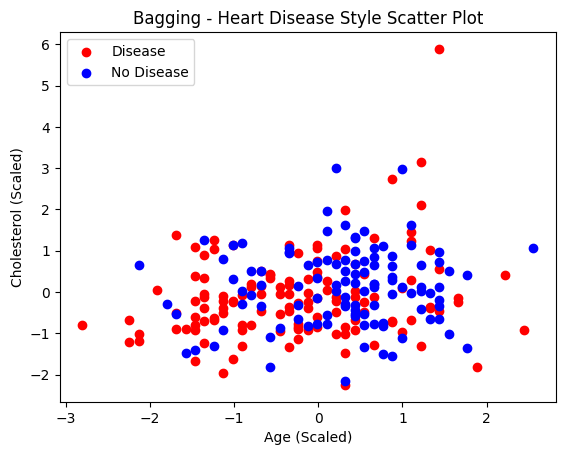

In [46]:
import matplotlib.pyplot as plt
age_idx = x.columns.get_loc('age')
chol_idx = x.columns.get_loc('chol')

plt.scatter(
    x_scaled[y_train==0, age_idx],
    x_scaled[y_train==0, chol_idx],
    color='red',
    label='Disease'
)
plt.scatter(
    x_scaled[y_train==1, age_idx],
    x_scaled[y_train==1, chol_idx],
    color='blue',
    label='No Disease'
)
plt.xlabel("Age (Scaled)")
plt.ylabel("Cholesterol (Scaled)")
plt.title("Bagging - Heart Disease Style Scatter Plot")
plt.legend()
plt.show()

In [66]:
print("DecisionTreee Accuracy_score:",accuracy_score(y_test,y_predict))
print("Bagging Accuracy:",accuracy_score(y_test,predict))
print("Random Forest Accuracy:",accuracy_score(y_test,p))
print("Extra Trees Accuracy:",accuracy_score(y_test,p))
print("Patching accuracy:",accuracy_score(y_test,pred))

DecisionTreee Accuracy_score: 0.7
Bagging Accuracy: 0.75
Random Forest Accuracy: 0.7833333333333333
Extra Trees Accuracy: 0.7833333333333333
Patching accuracy: 0.7666666666666667
